In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import matplotlib.pyplot as plt


In [7]:
# Data Paths
train_dir = "C:/Users/pc/Downloads/junkfood_dataset/training"
val_dir = "C:/Users/pc/Downloads/junkfood_dataset/validation"


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [9]:
val_datagen = ImageDataGenerator(rescale=1./255)


In [10]:
# Load Data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')

Found 3213 images belonging to 19 classes.
Found 4520 images belonging to 19 classes.


In [12]:
from tensorflow.keras.layers import BatchNormalization
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(19, activation='softmax')
])

In [13]:
from tensorflow.keras.layers import BatchNormalization

model.add(BatchNormalization())

In [14]:
# Compile Model
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(19, activation='softmax')
])

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator, validation_data=val_generator, epochs=30, callbacks=[early_stopping])



C:\Users\pc\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.4711 - loss: 1.8493 - val_accuracy: 0.8177 - val_loss: 0.5813
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.8447 - loss: 0.5036 - val_accuracy: 0.8560 - val_loss: 0.4466
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9036 - loss: 0.3124 - val_accuracy: 0.8515 - val_loss: 0.4588
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9211 - loss: 0.2492 - val_accuracy: 0.8615 - val_loss: 0.4283
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9341 - loss: 0.2066 - val_accuracy: 0.8628 - val_loss: 0.4301
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9354 - loss: 0.1884 - val_accuracy: 0.8569 - val_loss: 0.4636
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9488 - loss: 0.1540 - val_accuracy: 0.8666 - val_loss: 0.4207
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9515 - loss: 0.1466 - val_accu

In [17]:
model.save('junk_food_recognition.h5')

Text(0.5, 1.0, 'Accuracy')

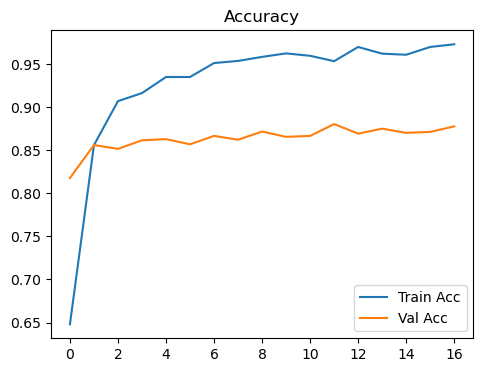

In [18]:
# Plot Accuracy & Loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

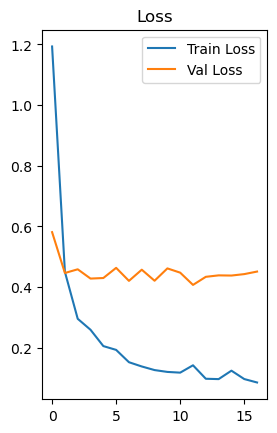

In [19]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image


In [21]:
#from tensorflow.keras.models import load_model
#model = load_model('junk_food_recognition.h5')

In [22]:
img_path = 'C:/Users/pc/Downloads/images (1).jpeg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print(f"Predicted Class: {predicted_class}")
# for predicting food name
food_dict = {
    0: 'Biryani', 1: 'Burger', 2: 'CheeseCake', 3: 'Chips', 4: 'Cookies',
    5: 'CrispyChicken', 6: 'French-fry', 7: 'Hotdogs', 8: 'Ice cream', 9: 'Kabab',
    10: 'Mac_and_cheese', 11: 'Meatloaf', 12: 'Muffin', 13: 'Nachos', 14: 'Noodles',
    15: 'Pizza', 16: 'Processed cheese', 17: 'Sandwich', 18: 'Waffles'
}



food_name = food_dict.get(predicted_class, "Unknown food") 

print(f"The predicted food is: {food_name}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: 8
The predicted food is: Ice cream


In [23]:
print(train_generator.class_indices)


{'Biryani': 0, 'Burger': 1, 'CheeseCake': 2, 'Chips': 3, 'Cookies': 4, 'CrispyChicken': 5, 'French-fry': 6, 'Hotdogs': 7, 'Ice cream': 8, 'Kabab': 9, 'Mac_and_cheese': 10, 'Meatloaf': 11, 'Muffin': 12, 'Nachos': 13, 'Noodles': 14, 'Pizza': 15, 'Processed cheese': 16, 'Sandwich': 17, 'Waffles': 18}
